In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import os

def live_plot_training_progress(csv_file, update_interval=3):
    """
    Динамически обновляемые графики обучения в Jupyter Notebook
    с фиксированным размером и читаемыми осями
    """
    # Инициализация фигуры и осей один раз
    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(20, 15))
    plt.close(fig)  # Закрываем, чтобы не дублировать вывод
    
    try:
        while True:
            # Проверка и чтение данных (как в предыдущем коде)
            if not os.path.exists(csv_file):
                print(f"Ожидание файла {csv_file}...")
                time.sleep(update_interval)
                continue
                
            try:
                df = pd.read_csv(csv_file)
                if df.empty:
                    time.sleep(update_interval)
                    continue
            except Exception as e:
                print(f"Ошибка чтения файла: {e}")
                time.sleep(update_interval)
                continue
                
            clear_output(wait=True)
            
            # Очистка осей
            for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
                ax.clear()
            
            # 1. График наград
            ax1.plot(df['episode'], df['episode_reward'], 'b-')
            ax1.set_title(f'Награда за эпизод (последняя: {df["episode_reward"].iloc[-1]:.2f})')
            ax1.set_ylabel('Награда')
            ax1.grid(True)
            ax1.tick_params(axis='x', labelrotation=45)  # Наклон подписей
            
            # 2. Средняя награда
            ax2.plot(df['episode'], df['mean_reward_100'], 'r-')
            ax2.set_title(f'Средняя награда (100 эп.)\nПоследняя: {df["mean_reward_100"].iloc[-1]:.2f}')
            ax2.set_ylabel('Награда')
            ax2.grid(True)
            ax2.tick_params(axis='x', labelrotation=45)
            
            # 3. Длина эпизода
            ax3.plot(df['episode'], df['episode_length'], 'g-', label=f'Длина\nПоследняя: {df["episode_length"].iloc[-1]}')
            ax3.plot(df['episode'], df['mean_length_100'], 'orange', label=f'Средняя (100)\nПоследняя: {df["mean_length_100"].iloc[-1]:.2f}')
            ax3.set_title('Длина эпизодов')
            ax3.set_ylabel('Шаги')
            ax3.legend()
            ax3.grid(True)
            ax3.tick_params(axis='x', labelrotation=45)
            
            # 4. Лосс актора
            ax4.plot(df['episode'], df['actor_loss'], 'm-')
            ax4.set_title(f'Лосс актора\nПоследний: {df["actor_loss"].iloc[-1]:.4f}')
            ax4.set_ylabel('Лосс')
            ax4.grid(True)
            ax4.tick_params(axis='x', labelrotation=45)
            
            # 5. Лосс критика
            ax5.plot(df['episode'], df['critic_loss'], 'c-')
            ax5.set_title(f'Лосс критика\nПоследний: {df["critic_loss"].iloc[-1]:.4f}')
            ax5.set_ylabel('Лосс')
            ax5.grid(True)
            ax5.tick_params(axis='x', labelrotation=45)
            
            # 6. Learning rate
            if 'learning_rate' in df.columns:
                ax6.plot(df['episode'], df['learning_rate'], 'y-')
                ax6.set_title(f'Learning Rate\nПоследний: {df["learning_rate"].iloc[-1]:.6f}')
                ax6.set_ylabel('LR')
                ax6.grid(True)
                ax6.tick_params(axis='x', labelrotation=45)
            else:
                ax6.axis('off')  # Скрываем если данных нет
            
            fig.tight_layout(pad=3.0)  # Увеличиваем отступы
            display(fig)
            
            time.sleep(update_interval)
            
    except KeyboardInterrupt:
        plt.close('all')
        print("Визуализация остановлена")
    except Exception as e:
        plt.close('all')
        print(f"Произошла ошибка: {e}")

/home/vitya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


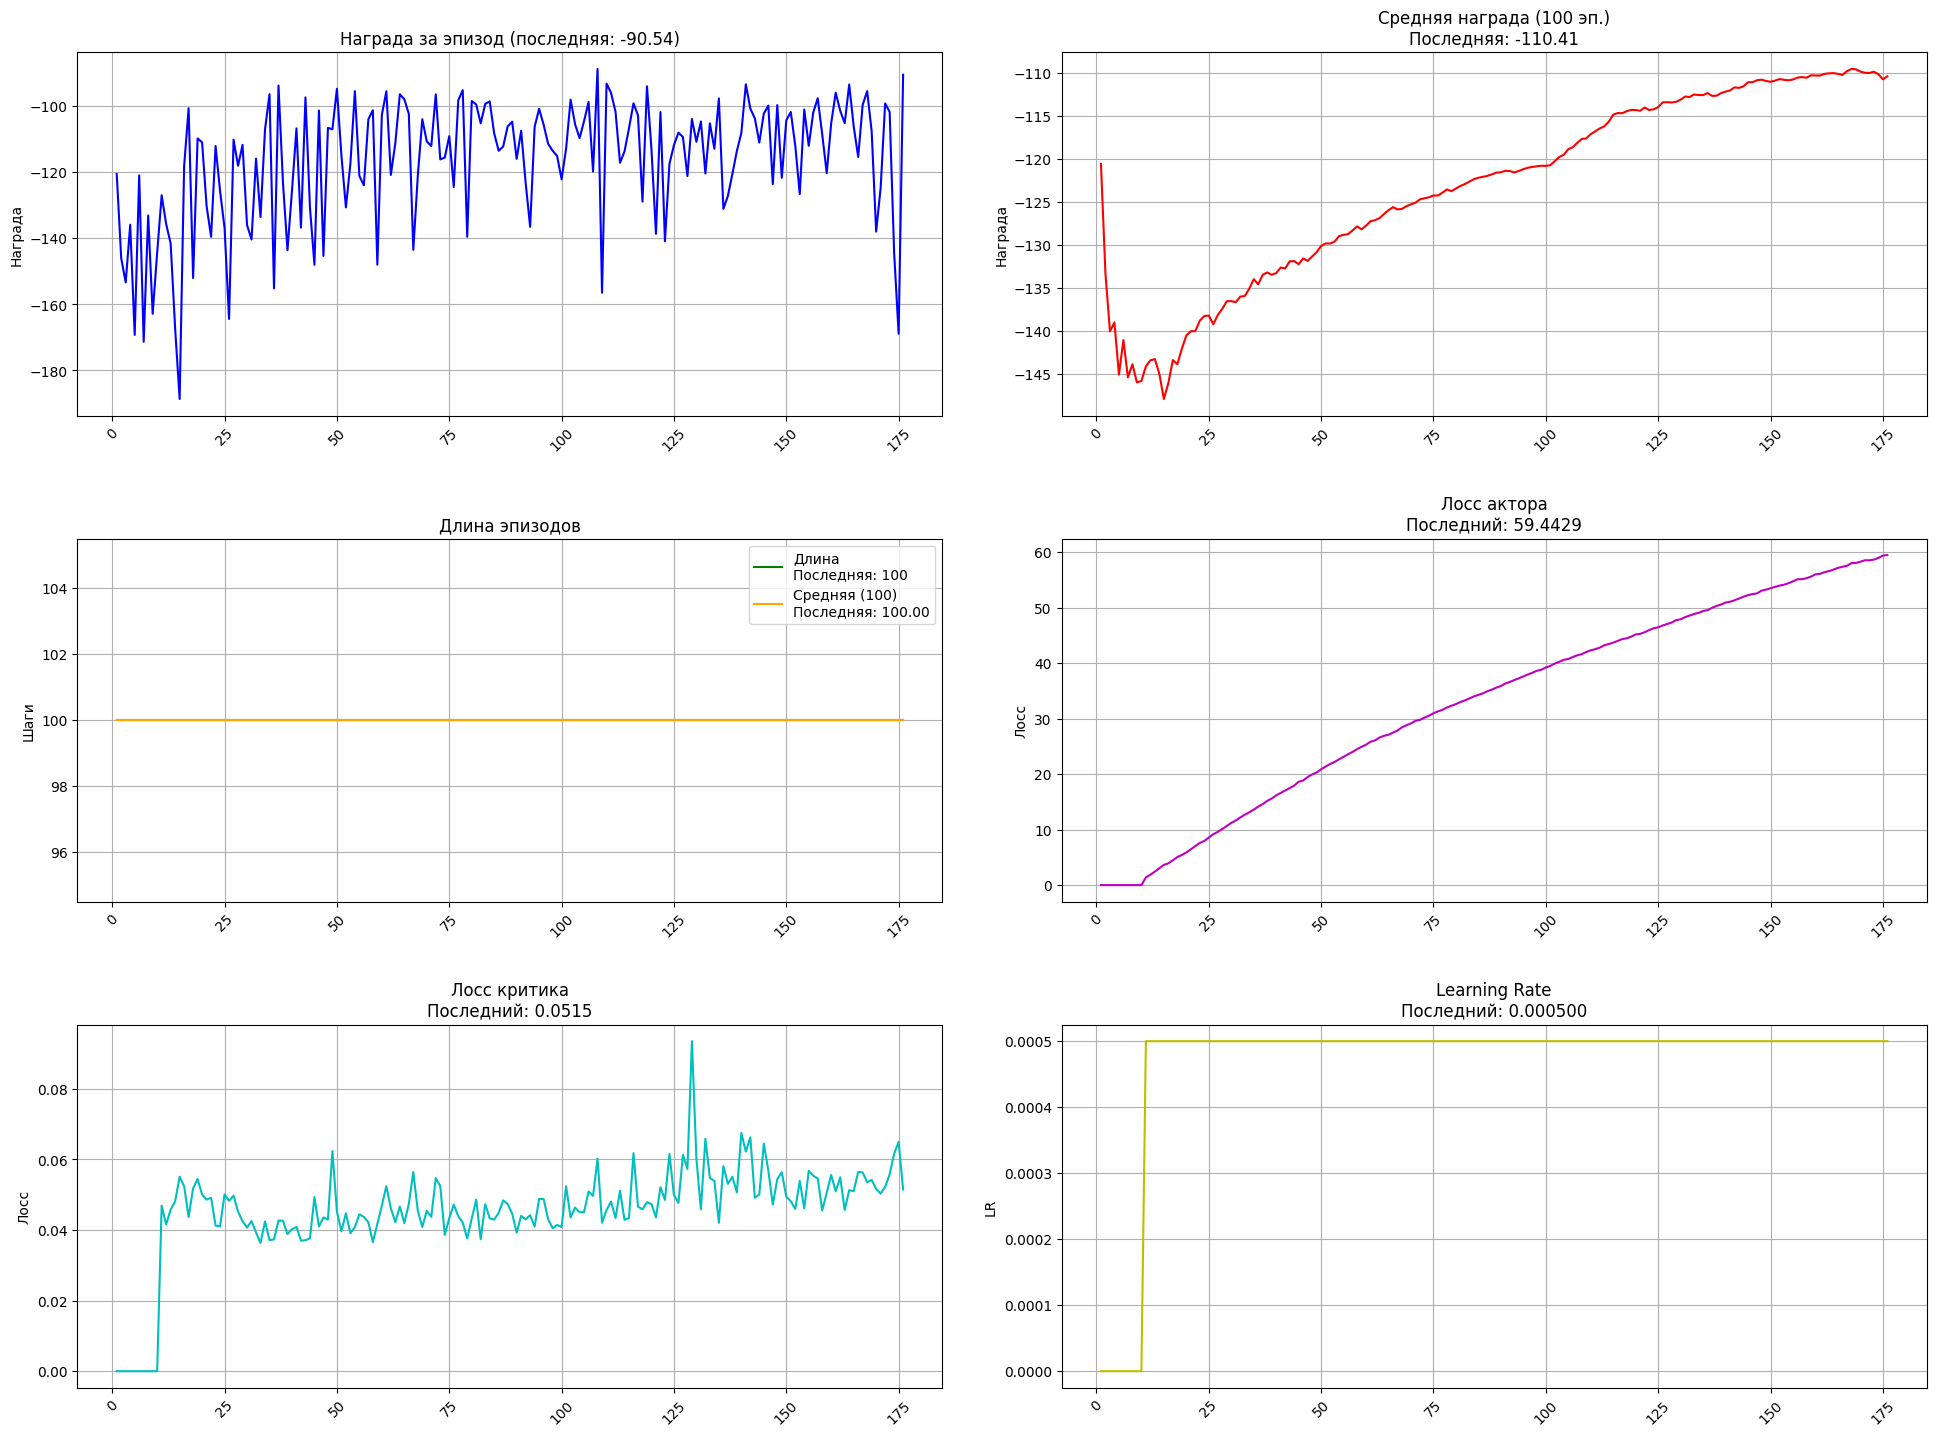

Визуализация остановлена


In [4]:
live_plot_training_progress('/home/vitya/diploma/roboarm/src/roboarm_rl/training_logs/20250521/training_log_20250522_032656.csv')

In [ ]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from tqdm import tqdm
import torch
from torchvision import transforms
from torchvision import models
from PIL import Image

In [ ]:
imgs_f = os.listdir('/path')
rwrds_f = os.listdir('/path')

imgs = {os.path.splitext(x)[0] for x in imgs_f}
rwrds = {os.path.splitext(x)[0] for x in rwrds_f}

common_names = sorted(list(imgs & rwrds))
embs = []
rwrds = []

_model = models.mobilenet_v3_small(weights=None)  # Не загружаем imagenet веса
_model.classifier = torch.nn.Identity()  # Удаляем классификатор
checkpoint = torch.load('/checkpoint.pth')
_model.load_state_dict(checkpoint)
_model.to('cuda')

transform = transforms.Compose([
        transforms.Resize(256),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

for name in tqdm(common_names):
    img_name = name + '.png'
    rwrd_name = name + '.txt'
    imarr = cv2.imread(f'/path/{img_name}')
    imarr = cv2.cvtColor(imarr, cv2.COLOR_BGR2RGB)
    imarr = transform(Image.fromarray(imarr)).unsqueeze(0)
    # print(imarr.size())
    with torch.no_grad():
        emb = _model(imarr.to('cuda')).squeeze(0).cpu().numpy()
    with open(f'/path/{rwrd_name}', 'r') as f:
        rwrd = np.array(f.read().split(',')).astype(float)
    
    embs.append(emb)
    rwrds.append(rwrd)

embs = np.array(embs)
rwrds = np.array(rwrds)

100%|██████████| 26492/26492 [04:16<00:00, 103.25it/s]


In [16]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embs)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embs)

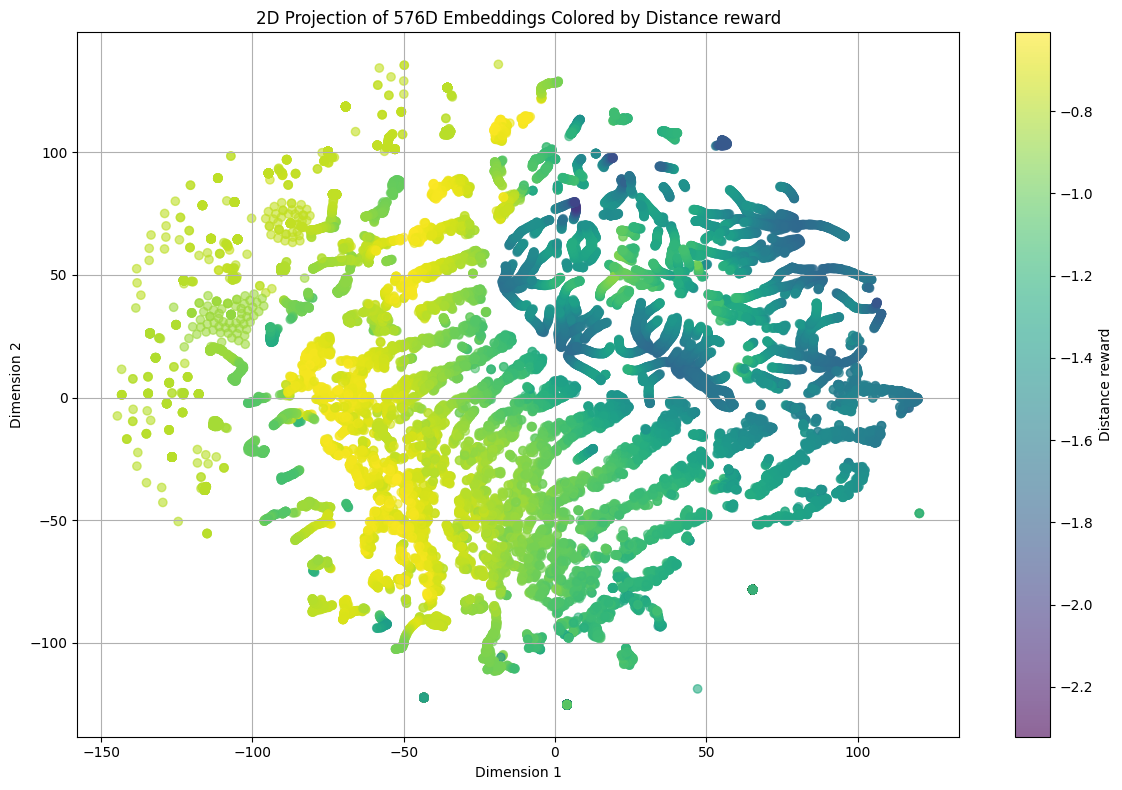

In [17]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 0],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Distance reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Distance reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

In [ ]:
imgs_f = os.listdir('/path')
rwrds_f = os.listdir('/path')

imgs = {os.path.splitext(x)[0] for x in imgs_f}
rwrds = {os.path.splitext(x)[0] for x in rwrds_f}

common_names = sorted(list(imgs & rwrds))
embs = []
rwrds = []

for name in tqdm(common_names):
    img_name = name + '.png'
    rwrd_name = name + '.txt'
    imarr = cv2.imread(f'/path/{img_name}')
    imarr = cv2.cvtColor(imarr, cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        emb = model(torch.from_numpy(imarr).permute(2, 0, 1).unsqueeze(0).float().to('cuda')).squeeze(0).cpu().numpy()
    with open(f'/path/{rwrd_name}', 'r') as f:
        rwrd = np.array(f.read().split(',')).astype(float)
    
    embs.append(emb)
    rwrds.append(rwrd)

embs = np.array(embs)
rwrds = np.array(rwrds)

100%|██████████| 64659/64659 [07:49<00:00, 137.79it/s]


In [31]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embs)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embs)

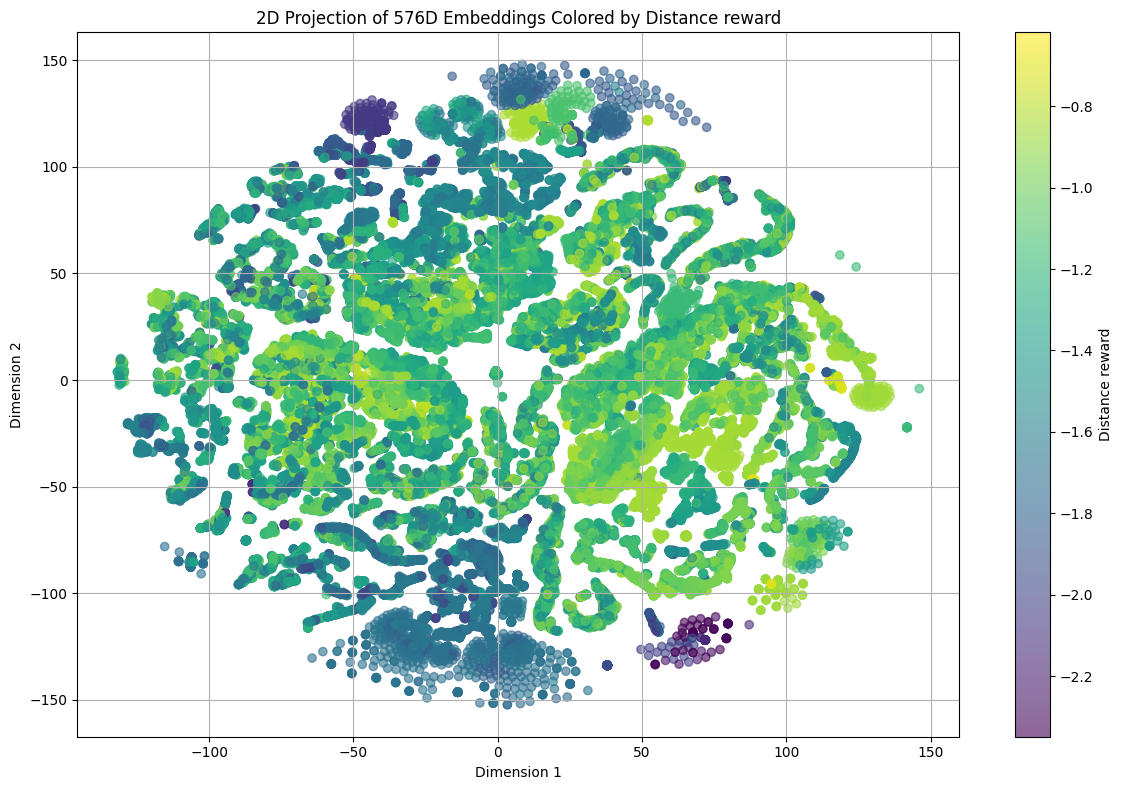

In [34]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 0],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Distance reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Distance reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()

In [ ]:
imgs_f = os.listdir('/path')
rwrds_f = os.listdir('/path')

imgs = {os.path.splitext(x)[0] for x in imgs_f}
rwrds = {os.path.splitext(x)[0] for x in rwrds_f}

common_names = sorted(list(imgs & rwrds))
embs = []
rwrds = []

for name in tqdm(common_names):
    img_name = name + '.png'
    rwrd_name = name + '.txt'
    imarr = cv2.imread(f'/path/{img_name}')
    imarr = cv2.cvtColor(imarr, cv2.COLOR_BGR2RGB)
    with torch.no_grad():
        emb = model(torch.from_numpy(imarr).permute(2, 0, 1).unsqueeze(0).float().to('cuda')).squeeze(0).cpu().numpy()
    with open(f'/path/{rwrd_name}', 'r') as f:
        rwrd = np.array(f.read().split(',')).astype(float)
    
    embs.append(emb)
    rwrds.append(rwrd)

embs = np.array(embs)
rwrds = np.array(rwrds)

100%|██████████| 44991/44991 [05:31<00:00, 135.52it/s]


In [6]:
# pca = PCA(n_components=2)
# embeddings_2d = pca.fit_transform(embs)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embs)

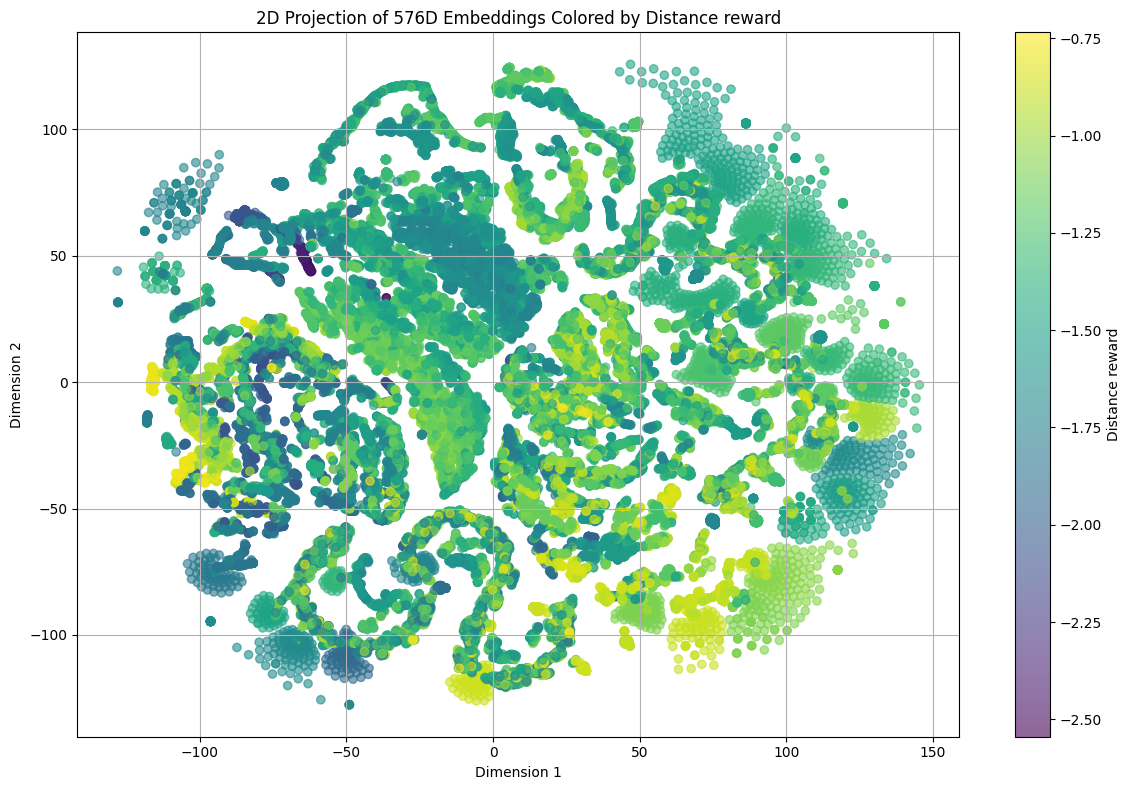

In [7]:
plt.figure(figsize=(12, 8))  # Увеличиваем размер для размещения colorbar

# Создаем scatter plot с цветами из rwrds[0]
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
            alpha=0.6, 
            c=rwrds[:, 0],
            cmap='viridis')  # Можно выбрать другую цветовую карту

# Добавляем colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Distance reward')  # Подпись colorbar

# Остальные элементы графика
plt.title('2D Projection of 576D Embeddings Colored by Distance reward')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.grid(True)

plt.tight_layout()  # Чтобы не обрезались подписи
plt.show()